# SIH Phase Demo
This notebook walks through the data pipeline, prediction, and visualizes SHAP plots.

In [14]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Set up matplotlib for better display
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Data and Artifacts

In [15]:
# Load models and pipeline
pipeline = joblib.load('pipeline.joblib')
predictor = joblib.load('ensemble.joblib')
timeline_pred = joblib.load('timeline.joblib')

# Load dataset
df = pd.read_csv('Revolution-main/indian_infrastructure_projects_dataset.csv')
X_raw = df.drop(columns=['delay_binary_label', 'Actual_Delay_Days', 'CRS', 'project_index'], errors='ignore')

# Transform data
X_tf = pipeline.transform(X_raw)

## 2. Make Predictions on a Sample

In [16]:
# Take a sample project
sample_idx = 0
X_sample = X_tf.iloc[[sample_idx]]

predictions = predictor.predict(X_sample)
print(f"Delay Probability: {predictions['delay_probability'][0]*100:.1f}%")
print(f"CRS Score: {predictions['crs'][0]:.1f}")

time_to_delay = timeline_pred.predict_time_to_delay(X_sample)[0]
print(f"Time to Delay: {time_to_delay:.0f} days")

Delay Probability: 0.2%
CRS Score: 67.8
Time to Delay: 90 days


## 3. Explanations and SHAP Visualizations

In [17]:
# Get the underlying model from predictor (e.g., first model in the ensemble or the meta-model)
# Note: For SHAP to work directly, we extract the XGBoost model or use TreeExplainer.
# Here we use DualParadigmExplainer which internally wraps LIME/SHAP.

from explainer import DualParadigmExplainer

# Initialize DualParadigmExplainer with a representative sample
explainer = DualParadigmExplainer(predictor, X_tf.columns.tolist(), X_tf.iloc[:100])
explanation = explainer.generate_explanation(X_sample, predictions)

print("Top Risk Drivers:")
for feature, importance in explanation['risk_drivers']:
    print(f"- {feature}: {importance:.3f}")

Top Risk Drivers:
- section_11_notification_days: 8.211
- terrain_risk_score: 0.497
- land_area_log: 0.117
- title_dispute_rate_percent: 0.104
- F_r: 0.084


C:\Users\usmed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\usmed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\usmed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## SHAP Summary Plot

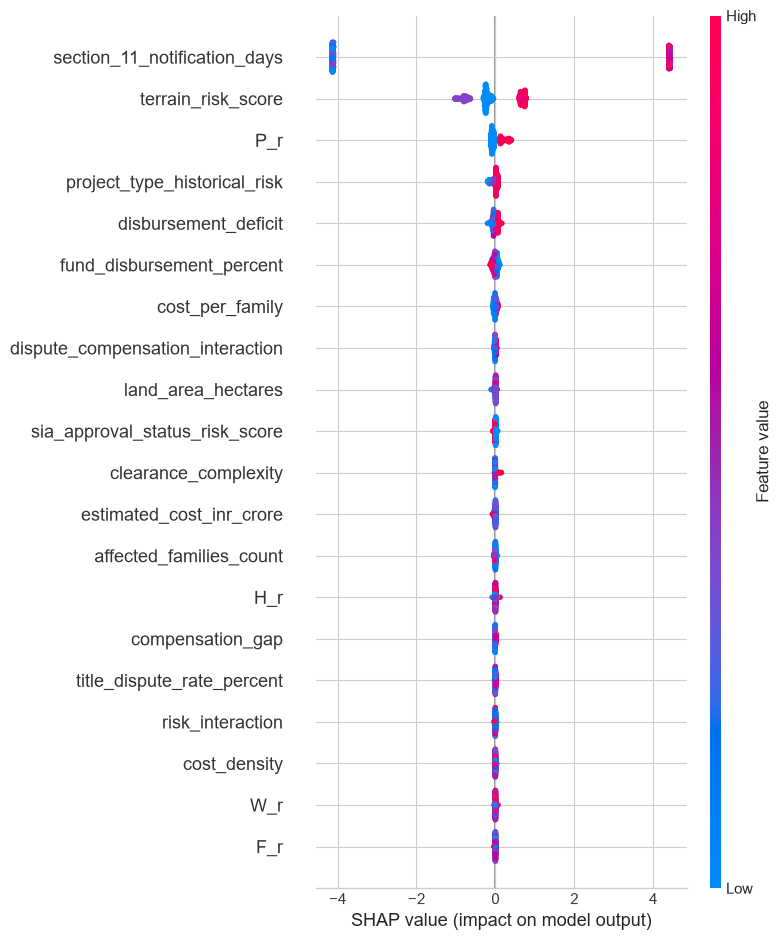

In [18]:
# To show SHAP plots directly, we can use shap library
# We'll use a subset of data to generate a summary plot
X_subset = X_tf.iloc[:500]

# If predictor uses XGBoost directly as one of its base models, we can explain it:
xgb_model = predictor.xgb_classifier

shap_explainer = shap.TreeExplainer(xgb_model)
shap_values = shap_explainer.shap_values(X_subset)

shap.summary_plot(shap_values, X_subset)